In [1]:
import os 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import random 
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter 
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0


In [2]:
def load_data(path):
    files = []
    labels = []

    for label in os.listdir(path):
        label_path = os.path.join(path, label)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                files.append(os.path.join(label_path, file))
                labels.append(label)    
    
    return files, labels 

In [3]:
path = os.path.join('plantvillage_dataset/color')
files, labels = load_data(path)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    files,
    labels,
    test_size=0.2,
    random_state=42, 
    stratify=labels
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, 
    temp_labels,
    test_size=0.5,
    random_state=42, 
    stratify=temp_labels
)

In [4]:
print("Total treino:", len(train_files))
print("Total validação:", len(val_files))
print("Total teste:", len(test_files))

print("Classes treino:", len(set(train_labels)))
print("Classes validação:", len(set(val_labels)))
print("Classes teste:", len(set(test_labels)))

print("\nDistribuição treino:")
print(Counter(train_labels))
print("\nDistribuição validação:")
print(Counter(val_labels))
print("\nDistribuição teste:")
print(Counter(test_labels))

Total treino: 43444
Total validação: 5430
Total teste: 5431
Classes treino: 38
Classes validação: 38
Classes teste: 38

Distribuição treino:
Counter({'Orange___Haunglongbing_(Citrus_greening)': 4405, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 4286, 'Soybean___healthy': 4072, 'Peach___Bacterial_spot': 1837, 'Tomato___Bacterial_spot': 1702, 'Tomato___Late_blight': 1527, 'Squash___Powdery_mildew': 1468, 'Tomato___Septoria_leaf_spot': 1417, 'Tomato___Spider_mites Two-spotted_spider_mite': 1341, 'Apple___healthy': 1316, 'Tomato___healthy': 1273, 'Blueberry___healthy': 1202, 'Pepper,_bell___healthy': 1182, 'Tomato___Target_Spot': 1123, 'Grape___Esca_(Black_Measles)': 1106, 'Corn_(maize)___Common_rust_': 953, 'Grape___Black_rot': 944, 'Corn_(maize)___healthy': 930, 'Strawberry___Leaf_scorch': 887, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 861, 'Cherry_(including_sour)___Powdery_mildew': 842, 'Tomato___Early_blight': 800, 'Potato___Early_blight': 800, 'Potato___Late_blight': 800, 'Pepper,_b

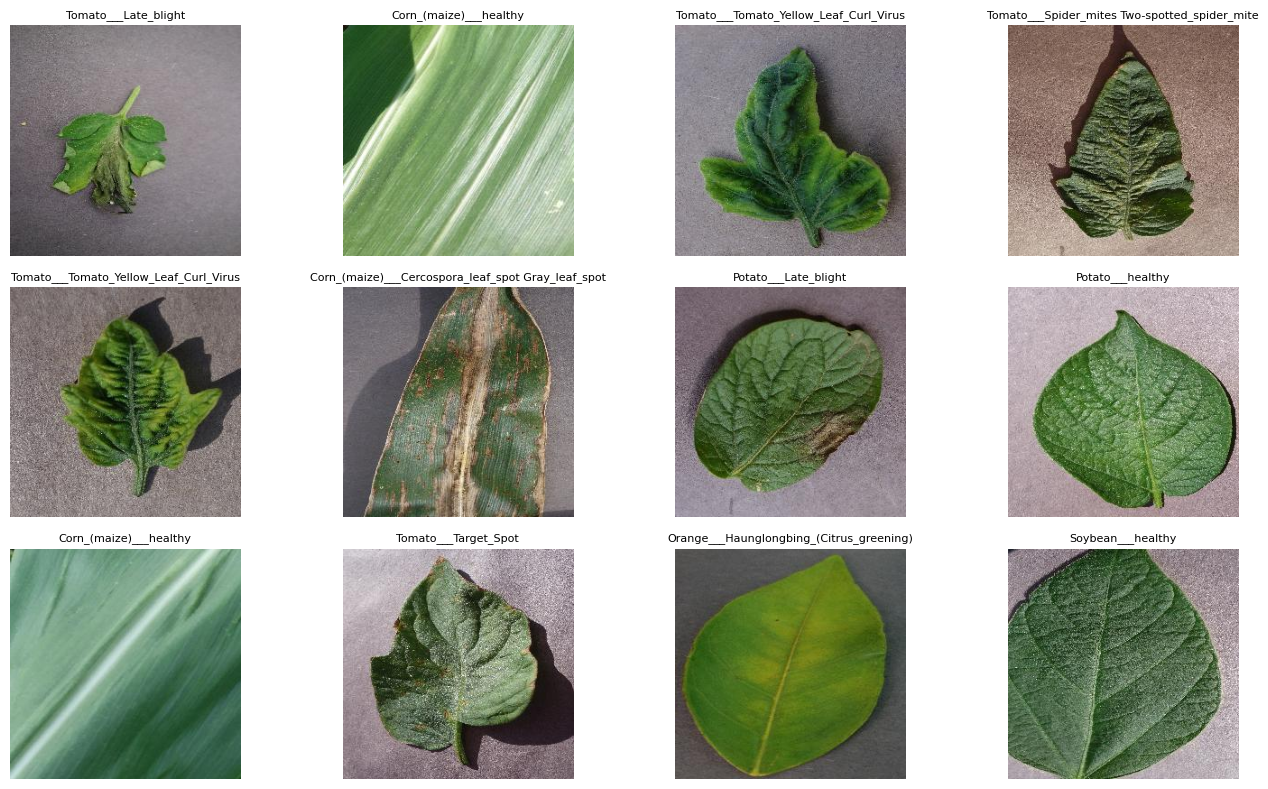

In [5]:
indices = random.sample(range(len(train_files)), 12)

plt.figure(figsize=(14, 8))

for i, idx in enumerate(indices):
    img = Image.open(train_files[idx]).convert("RGB")
    label = train_labels[idx]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
class_names = sorted(set(labels))

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
num_classes = len(class_names)

print("Número de classes:", len(class_names))
print(class_to_idx)

Número de classes: 38
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Lat

In [7]:
train_label_ids = [class_to_idx[label] for label in train_labels]
val_label_ids = [class_to_idx[label] for label in val_labels]
test_label_ids = [class_to_idx[label] for label in test_labels]

In [8]:
img_size = (224, 224)
batch_size = 16

def load_image(image_path, label_id): 
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
   
    return image, label_id

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_label_ids))
val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_label_ids))
test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_label_ids))

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_files), seed=42)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

In [11]:
for images, targets in train_ds.take(1):
    print(images.shape)
    print(targets.shape)
    print(targets[:10])

(16, 224, 224, 3)
(16,)
tf.Tensor([26  1 14  1 24 12 16 30 15 16], shape=(10,), dtype=int32)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..216.16835].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..212.02545].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..206.60692].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..240.53574].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [45.071423..254.67346].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [10.326305..225.79619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.13268].
Clipping input data to

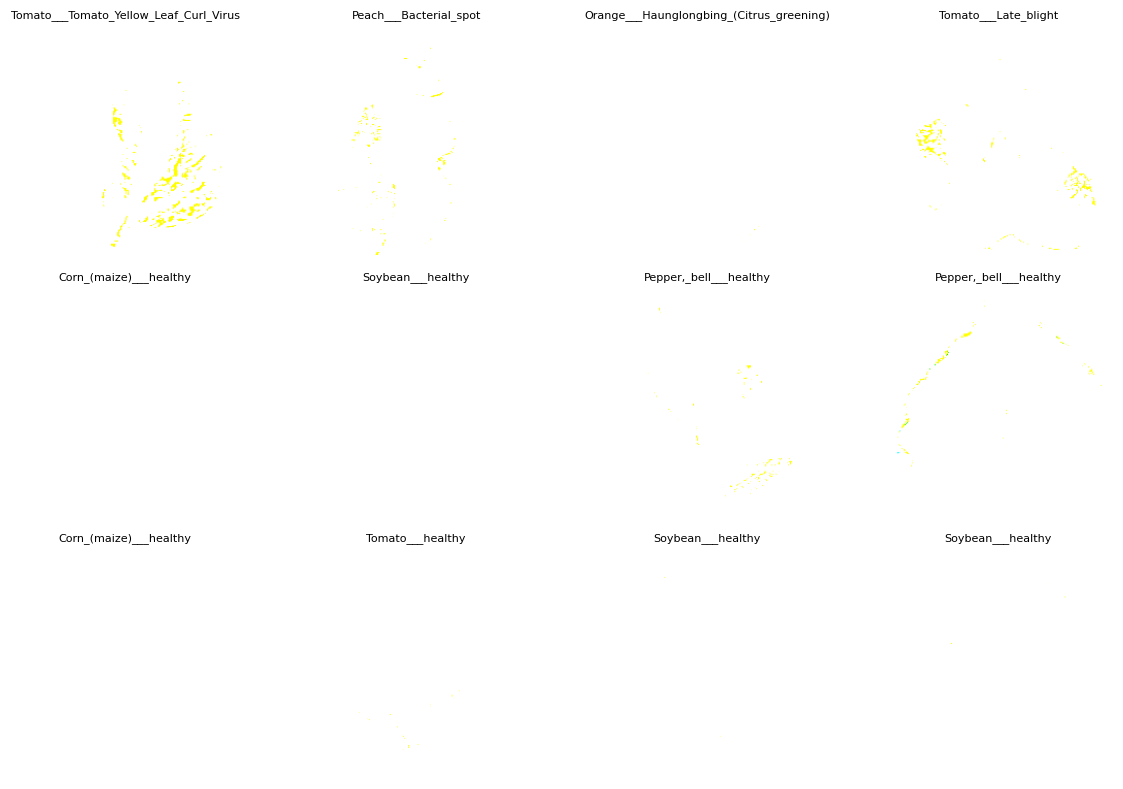

In [12]:
for images, targets in train_ds.take(1):
    plt.figure(figsize=(12, 8))

    for i in range(12):
        label_id = int(targets[i])
        label_name = idx_to_class[label_id]

        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        plt.title(label_name, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [13]:
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5


In [ ]:
val_loss, val_acc = model.evaluate(val_ds)

print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")